In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import collections

RAW = '../data/01_raw/'

train = pd.read_csv(RAW + 'train_raw.csv')
test  = pd.read_csv(RAW + 'test.csv')
test_labels = pd.read_csv(RAW + 'test_labels.csv')
updates = pd.read_csv(RAW + 'train_updates_20220929.csv')

test = test.merge(test_labels, on='seq_id')

print('train:', train.shape)
print('test: ', test.shape)
train.head(2)

train: (31390, 5)
test:  (2413, 5)


,seq_id,protein_sequence,pH,data_source,tm
0,0,AAAAKAAALALLGEAPEVVDIWLPAGWRQPFRVFRLERKGDGVLVG...,7.0,doi.org/10.1038/s41592-020-0801-4,75.7
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5


## Missing values & data quality

In [2]:
print('=== train null counts ===')
print(train.isnull().sum())
print()
print('=== test null counts ===')
print(test.isnull().sum())
print()

# train_updates: rows with all-NaN = deletions from train
deleted = updates[updates['protein_sequence'].isna()]['seq_id'].tolist()
modified = updates[updates['protein_sequence'].notna()]
print(f'train_updates: {len(deleted)} rows marked for deletion, {len(modified)} modified rows')

=== train null counts ===
seq_id                 0
protein_sequence       0
pH                   286
data_source         3347
tm                     0
dtype: int64

=== test null counts ===
seq_id              0
protein_sequence    0
pH                  0
data_source         0
tm                  0
dtype: int64

train_updates: 2409 rows marked for deletion, 25 modified rows


In [3]:
# drop rows with missing sequence or tm
train_clean = train.dropna(subset=['protein_sequence', 'tm']).copy()
print(f'train after dropping nulls: {len(train_clean)} rows (dropped {len(train) - len(train_clean)})')

train after dropping nulls: 31390 rows (dropped 0)


## Non-standard amino acids

In [4]:
STANDARD_AA = set('ACDEFGHIKLMNPQRSTVWY')

def nonstandard_chars(sequences):
    chars = set(''.join(sequences)) - STANDARD_AA
    counts = collections.Counter(c for seq in sequences for c in seq if c not in STANDARD_AA)
    return chars, counts

ns_chars, ns_counts = nonstandard_chars(train_clean['protein_sequence'])
print('Non-standard characters in train:', ns_counts)

ns_chars_t, ns_counts_t = nonstandard_chars(test['protein_sequence'].dropna())
print('Non-standard characters in test: ', ns_counts_t)

Non-standard characters in train: Counter()
Non-standard characters in test:  Counter()


## Sequence length

train: min=5, median=336, mean=448, max=32767
test: min=220, median=221, mean=221, max=221


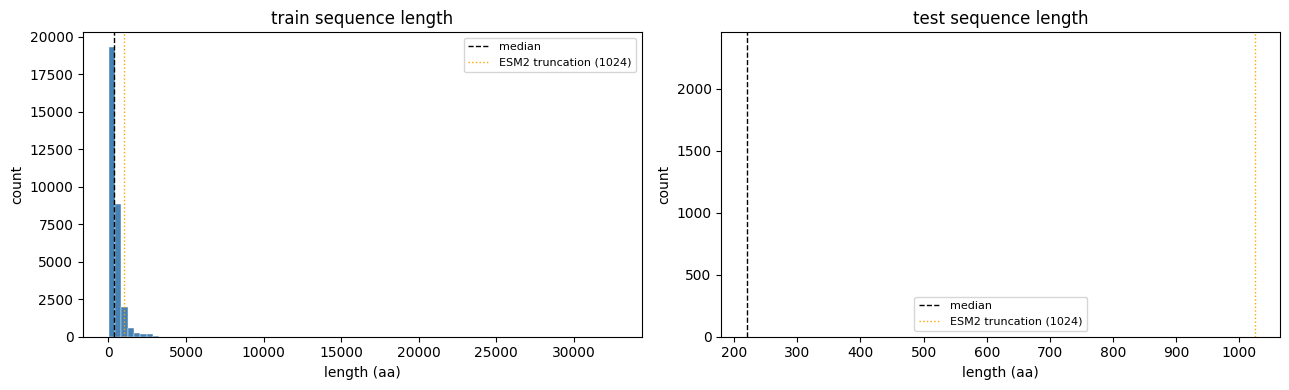

6.2% of train sequences exceed ESM2 max length of 1024


In [5]:
train_clean['seq_len'] = train_clean['protein_sequence'].str.len()
test['seq_len'] = test['protein_sequence'].str.len()

for label, df in [('train', train_clean), ('test', test)]:
    print(f'{label}: min={df.seq_len.min()}, median={df.seq_len.median():.0f}, '
          f'mean={df.seq_len.mean():.0f}, max={df.seq_len.max()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, df, color) in zip(axes, [
    ('train', train_clean, 'steelblue'),
    ('test',  test,        'tomato'),
]):
    ax.hist(df['seq_len'], bins=80, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(df['seq_len'].median(), color='black', linestyle='--', linewidth=1, label='median')
    ax.axvline(1024, color='orange', linestyle=':', linewidth=1, label='ESM2 truncation (1024)')
    ax.set_title(f'{label} sequence length')
    ax.set_xlabel('length (aa)')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

pct_truncated = (train_clean['seq_len'] > 1024).mean() * 100
print(f'{pct_truncated:.1f}% of train sequences exceed ESM2 max length of 1024')

## Amino acid composition

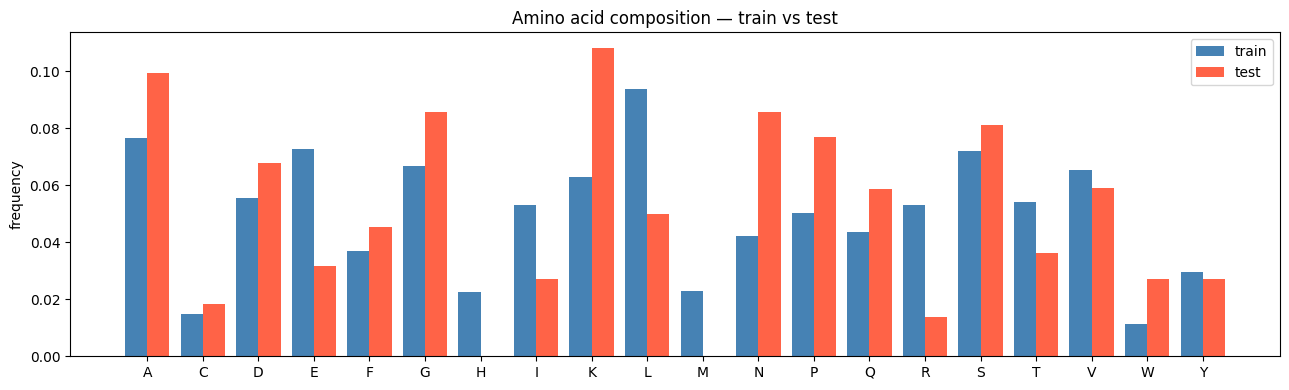

In [6]:
def aa_frequencies(sequences):
    counter = collections.Counter(''.join(sequences))
    total = sum(counter.values())
    return {aa: counter.get(aa, 0) / total for aa in sorted(STANDARD_AA)}

train_freqs = aa_frequencies(train_clean['protein_sequence'])
test_freqs  = aa_frequencies(test['protein_sequence'].dropna())

aas = sorted(STANDARD_AA)
x = np.arange(len(aas))
w = 0.4

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, [train_freqs[a] for a in aas], width=w, label='train', color='steelblue')
ax.bar(x + w/2, [test_freqs[a]  for a in aas], width=w, label='test',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_ylabel('frequency')
ax.set_title('Amino acid composition — train vs test')
ax.legend()
plt.tight_layout()
plt.show()

## Target (Tm) distribution

train: min=-1.0, median=48.0, mean=49.1, max=130.0, std=14.0
test: min=28.9, median=75.3, mean=72.2, max=81.7, std=7.5


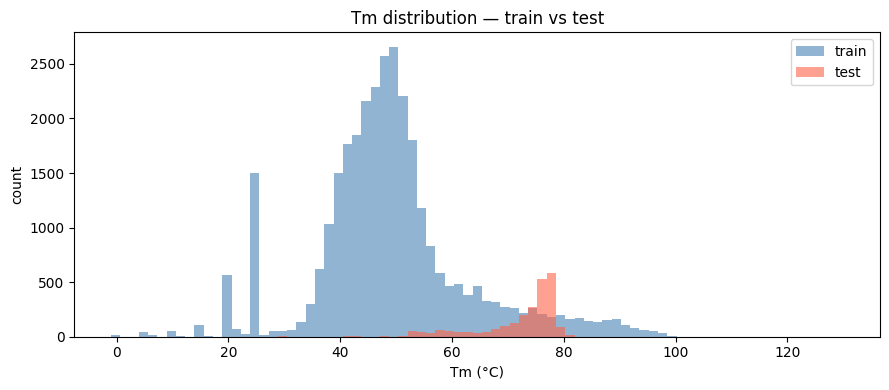

In [7]:
for label, df in [('train', train_clean), ('test', test)]:
    print(f'{label}: min={df.tm.min():.1f}, median={df.tm.median():.1f}, '
          f'mean={df.tm.mean():.1f}, max={df.tm.max():.1f}, std={df.tm.std():.1f}')

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(
    min(train_clean['tm'].min(), test['tm'].min()),
    max(train_clean['tm'].max(), test['tm'].max()),
    80
)
ax.hist(train_clean['tm'], bins=bins, alpha=0.6, label='train', color='steelblue')
ax.hist(test['tm'],        bins=bins, alpha=0.6, label='test',  color='tomato')
ax.set_xlabel('Tm (°C)')
ax.set_ylabel('count')
ax.set_title('Tm distribution — train vs test')
ax.legend()
plt.tight_layout()
plt.show()

## pH distribution

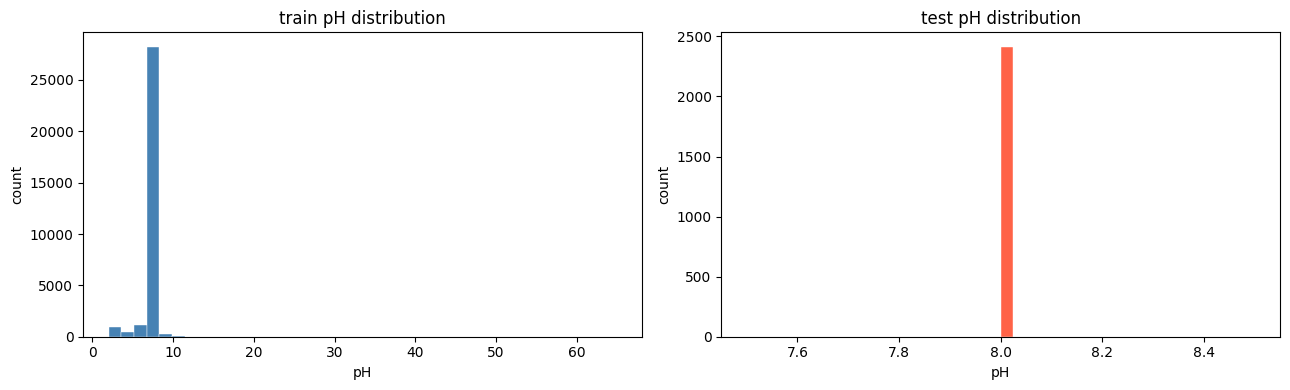

train pH nulls: 286
test  pH nulls: 0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, df, color) in zip(axes, [
    ('train', train_clean, 'steelblue'),
    ('test',  test,        'tomato'),
]):
    ax.hist(df['pH'].dropna(), bins=40, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} pH distribution')
    ax.set_xlabel('pH')
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

print('train pH nulls:', train_clean['pH'].isna().sum())
print('test  pH nulls:', test['pH'].isna().sum())

## Data source breakdown

In [9]:
source_stats = train_clean.groupby('data_source')['tm'].agg(['count', 'mean', 'std', 'min', 'max'])
source_stats.columns = ['n', 'tm_mean', 'tm_std', 'tm_min', 'tm_max']
print(source_stats.sort_values('n', ascending=False).to_string())

                                                                     n     tm_mean     tm_std  tm_min  tm_max
data_source                                                                                                  
doi.org/10.1038/s41592-020-0801-4                                24525   50.883800  11.839643    27.6    99.0
10.1021/acscatal.9b05223                                           211   61.988626   1.882289    54.5    71.0
10.1016/j.bpc.2006.10.014                                          185   48.802162   5.169770    34.4    57.9
10.7554/eLife.54639                                                151   43.584106   3.784602    33.0    57.8
10.1007/s00253-018-8872-1                                           84   53.916667   2.981705    45.0    63.5
10.1093/molbev/msw182                                               78   57.729487   8.175702    40.0    73.9
10.1371/journal.pone.0176255                                        77   39.475325   1.653159    34.9    46.0
10.1002/pr

/tmp/ipykernel_19701/3743416795.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[s.split('/')[-1][:30] for s in top_sources], vert=True)


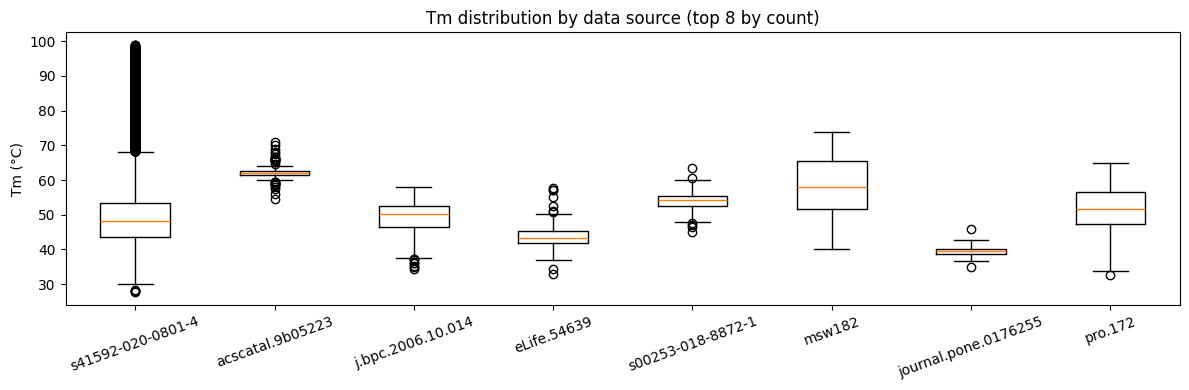

In [10]:
top_sources = source_stats.sort_values('n', ascending=False).head(8).index
fig, ax = plt.subplots(figsize=(12, 4))
data_to_plot = [train_clean[train_clean['data_source'] == s]['tm'].values for s in top_sources]
ax.boxplot(data_to_plot, labels=[s.split('/')[-1][:30] for s in top_sources], vert=True)
ax.set_ylabel('Tm (°C)')
ax.set_title('Tm distribution by data source (top 8 by count)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Correlations: Tm vs sequence length and pH

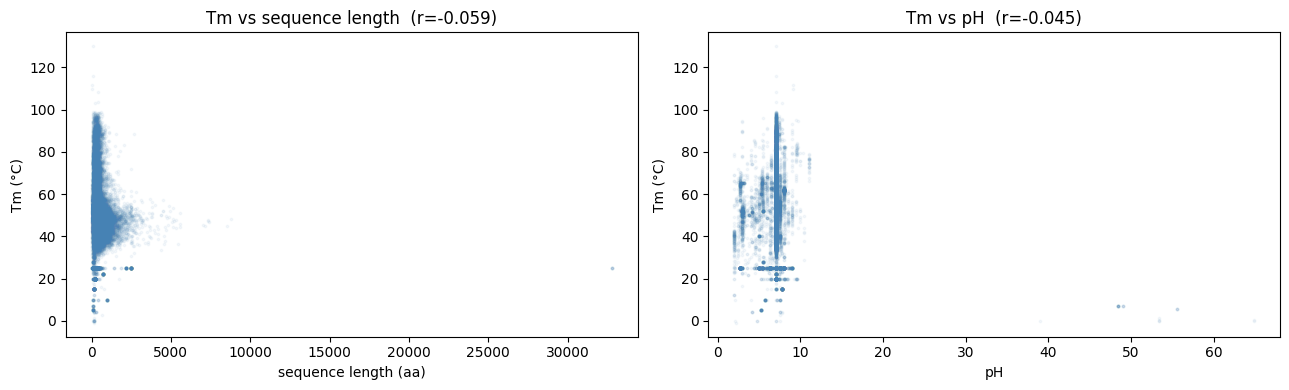

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tm vs sequence length
ax = axes[0]
ax.scatter(train_clean['seq_len'], train_clean['tm'], alpha=0.05, s=3, color='steelblue')
r = train_clean[['seq_len', 'tm']].corr().iloc[0, 1]
ax.set_xlabel('sequence length (aa)')
ax.set_ylabel('Tm (°C)')
ax.set_title(f'Tm vs sequence length  (r={r:.3f})')

# Tm vs pH
ax = axes[1]
ax.scatter(train_clean['pH'], train_clean['tm'], alpha=0.05, s=3, color='steelblue')
r_ph = train_clean[['pH', 'tm']].corr().iloc[0, 1]
ax.set_xlabel('pH')
ax.set_ylabel('Tm (°C)')
ax.set_title(f'Tm vs pH  (r={r_ph:.3f})')

plt.tight_layout()
plt.show()

## Duplicate sequences

In [12]:
dupes = train_clean[train_clean.duplicated(['protein_sequence', 'pH'], keep=False)]
n_pairs = dupes.groupby(['protein_sequence', 'pH']).ngroups
print(f'Rows with duplicate (sequence, pH) pairs: {len(dupes)} across {n_pairs} unique pairs')

if len(dupes) > 0:
    tm_spread = dupes.groupby(['protein_sequence', 'pH'])['tm'].agg(['min', 'max', 'count'])
    tm_spread['range'] = tm_spread['max'] - tm_spread['min']
    print(f'Max Tm range for same (sequence, pH): {tm_spread["range"].max():.1f}°C')
    print(tm_spread.sort_values('range', ascending=False).head(5).to_string())

Rows with duplicate (sequence, pH) pairs: 2377 across 995 unique pairs
Max Tm range for same (sequence, pH): 71.5°C
                                                                                                                                                                                                                                                                                                                                                                               min   max  count  range
protein_sequence                                                                                                                                                                                                                                                                                                                                                         pH                           
MVKVKFKYKGEEKEVDTSKIKKVWRVGKMISFTYDDNGKTGRGAVSEKDAPKELLDMLARAEREKK                                    

## Train / test sequence overlap

In [13]:
train_seqs = set(train_clean['protein_sequence'])
test_seqs  = set(test['protein_sequence'].dropna())
overlap = train_seqs & test_seqs
print(f'Exact sequence overlap: {len(overlap)} sequences ({len(overlap)/len(test_seqs)*100:.1f}% of test)')

Exact sequence overlap: 0 sequences (0.0% of test)


## Test set mutation analysis (wildtype-anchored)

In [14]:
WILDTYPE = 'VPVNPEPDATSVENVALKTGSGDSQSDPIKADLEVKGQSALPFDVDCWAILCKGAPNVLQRVNEKTKNSNRDRSGANKGPFKDPQKWGIKALPPKNPSWSAQDFKSPEEYAFASSLQGGTNAILAPVNLASQNSQGGVLNGFYSANKVAQFDPSKPQQTKGTWFQITKFTGAAGPYCKALGSNDKSVCDKNKNIAGDWGFDPAKWAYQYDEKNNKFNYVGK'

wt_rows = test[test['protein_sequence'] == WILDTYPE]
if len(wt_rows):
    wt_tm = wt_rows['tm'].values[0]
    print(f'Wildtype found in test set — Tm = {wt_tm:.1f}°C')
else:
    wt_tm = None
    print('Wildtype sequence not found exactly in test set')

wt_len = len(WILDTYPE)
print(f'Wildtype length: {wt_len} aa')

# sequences with different length than wildtype can't be compared position-by-position
len_mismatch = (test['protein_sequence'].str.len() != wt_len).sum()
print(f'Test sequences with different length than wildtype: {len_mismatch}')

Wildtype found in test set — Tm = 77.4°C
Wildtype length: 221 aa
Test sequences with different length than wildtype: 77


n_mutations
0       1
1    2335


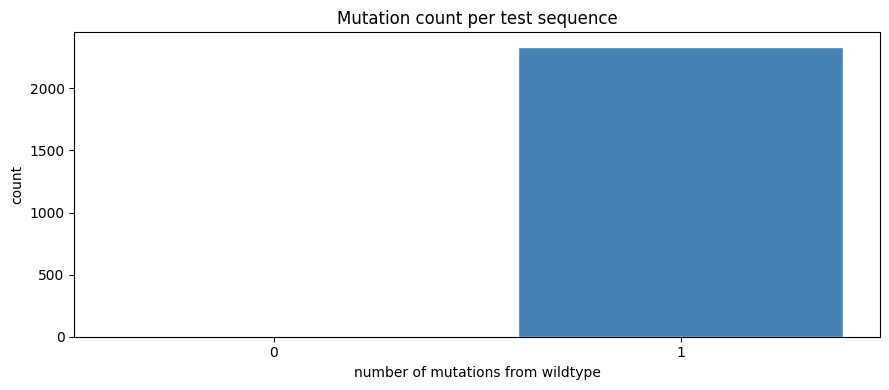

In [15]:
# restrict to same-length sequences for positional analysis
test_mut = test[test['protein_sequence'].str.len() == wt_len].copy()

def count_mutations(seq):
    return sum(a != b for a, b in zip(seq, WILDTYPE))

test_mut['n_mutations'] = test_mut['protein_sequence'].apply(count_mutations)
if wt_tm is not None:
    test_mut['delta_tm'] = test_mut['tm'] - wt_tm

print(test_mut['n_mutations'].value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(9, 4))
counts = test_mut['n_mutations'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('number of mutations from wildtype')
ax.set_ylabel('count')
ax.set_title('Mutation count per test sequence')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

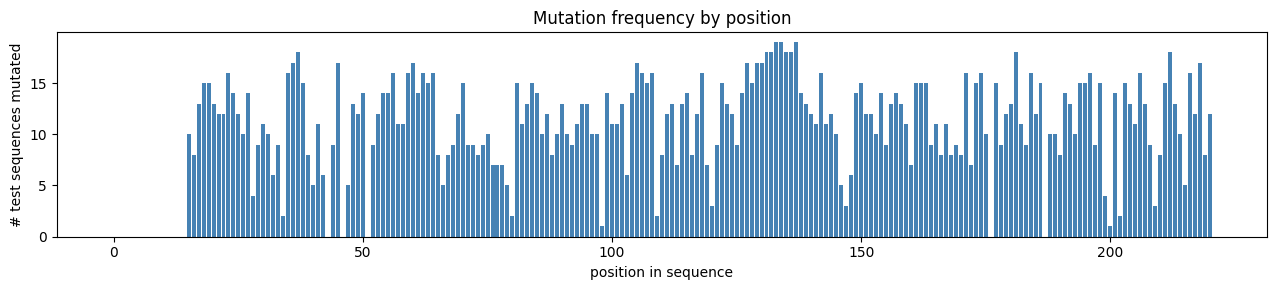

201 of 221 positions are mutated at least once


In [16]:
# mutated position frequency
position_counts = np.zeros(wt_len, dtype=int)
for seq in test_mut['protein_sequence']:
    for i, (a, b) in enumerate(zip(seq, WILDTYPE)):
        if a != b:
            position_counts[i] += 1

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(range(wt_len), position_counts, color='steelblue', linewidth=0)
ax.set_xlabel('position in sequence')
ax.set_ylabel('# test sequences mutated')
ax.set_title('Mutation frequency by position')
plt.tight_layout()
plt.show()

n_mutated_positions = (position_counts > 0).sum()
print(f'{n_mutated_positions} of {wt_len} positions are mutated at least once')

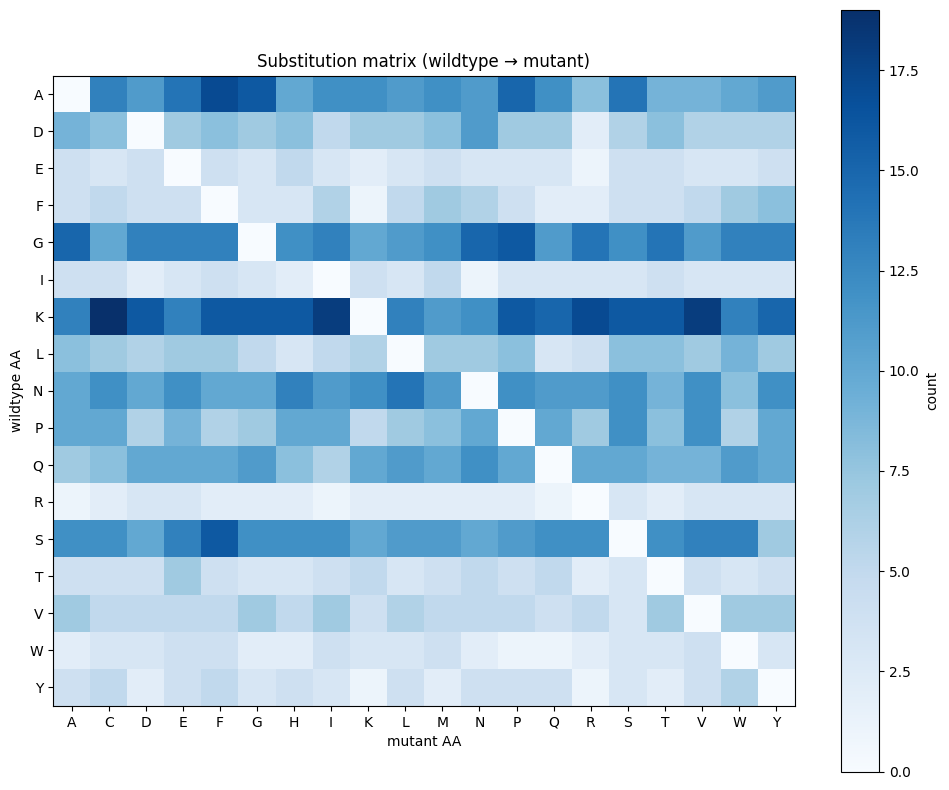

In [17]:
# substitution matrix: wildtype AA → mutant AA
sub_matrix = pd.DataFrame(0, index=sorted(STANDARD_AA), columns=sorted(STANDARD_AA))

for seq in test_mut['protein_sequence']:
    for wt_aa, mut_aa in zip(WILDTYPE, seq):
        if wt_aa != mut_aa and wt_aa in STANDARD_AA and mut_aa in STANDARD_AA:
            sub_matrix.loc[wt_aa, mut_aa] += 1

# drop rows/cols with no mutations
sub_matrix = sub_matrix.loc[sub_matrix.sum(axis=1) > 0, sub_matrix.sum(axis=0) > 0]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub_matrix.values, cmap='Blues')
ax.set_xticks(range(len(sub_matrix.columns)))
ax.set_yticks(range(len(sub_matrix.index)))
ax.set_xticklabels(sub_matrix.columns)
ax.set_yticklabels(sub_matrix.index)
ax.set_xlabel('mutant AA')
ax.set_ylabel('wildtype AA')
ax.set_title('Substitution matrix (wildtype → mutant)')
plt.colorbar(im, ax=ax, label='count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19701/3034323425.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


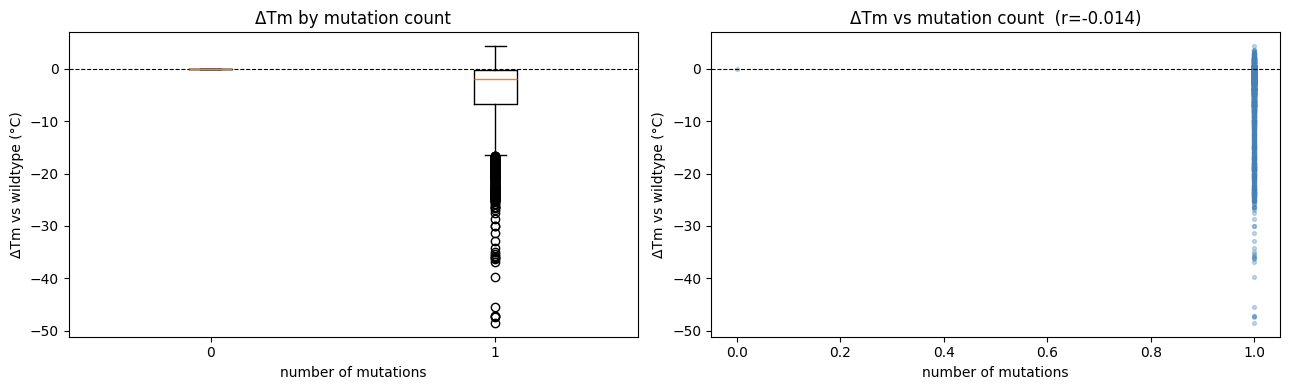

In [18]:
# ΔTm by mutation count (requires wildtype Tm)
if wt_tm is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    groups = [test_mut[test_mut['n_mutations'] == n]['delta_tm'].values
              for n in sorted(test_mut['n_mutations'].unique())]
    labels = sorted(test_mut['n_mutations'].unique())
    ax.boxplot(groups, labels=labels)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('number of mutations')
    ax.set_ylabel('ΔTm vs wildtype (°C)')
    ax.set_title('ΔTm by mutation count')

    ax = axes[1]
    ax.scatter(test_mut['n_mutations'], test_mut['delta_tm'], alpha=0.3, s=8, color='steelblue')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    r = test_mut[['n_mutations', 'delta_tm']].corr().iloc[0, 1]
    ax.set_xlabel('number of mutations')
    ax.set_ylabel('ΔTm vs wildtype (°C)')
    ax.set_title(f'ΔTm vs mutation count  (r={r:.3f})')

    plt.tight_layout()
    plt.show()
else:
    print('Skipped: wildtype Tm not available')

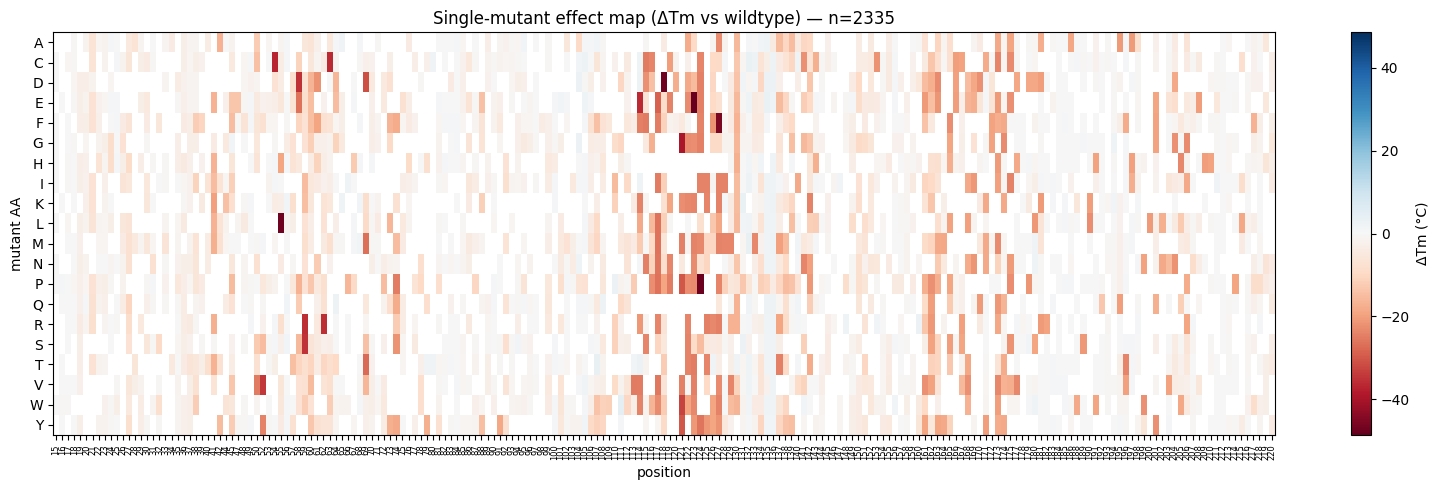

In [19]:
# single-mutant effect map: position vs ΔTm
if wt_tm is not None:
    singles = test_mut[test_mut['n_mutations'] == 1].copy()

    # extract (position, mutant_aa) for each single mutant
    def parse_single_mutation(seq):
        for i, (w, m) in enumerate(zip(WILDTYPE, seq)):
            if w != m:
                return i, m
        return None, None

    singles[['mut_pos', 'mut_aa']] = singles['protein_sequence'].apply(
        lambda s: pd.Series(parse_single_mutation(s))
    )

    pivot = singles.pivot_table(index='mut_aa', columns='mut_pos', values='delta_tm', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(pivot.values, cmap='RdBu', aspect='auto',
                   vmin=-np.nanmax(np.abs(pivot.values)), vmax=np.nanmax(np.abs(pivot.values)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=6, rotation=90)
    ax.set_xlabel('position')
    ax.set_ylabel('mutant AA')
    ax.set_title(f'Single-mutant effect map (ΔTm vs wildtype) — n={len(singles)}')
    plt.colorbar(im, ax=ax, label='ΔTm (°C)')
    plt.tight_layout()
    plt.show()
else:
    print('Skipped: wildtype Tm not available')

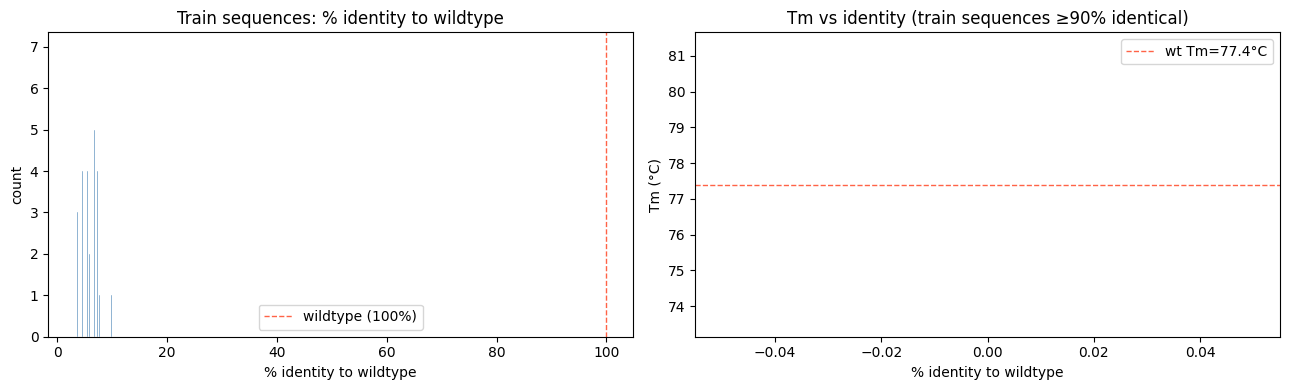

Train sequences identical to wildtype: 0
Train sequences ≥90% identical: 0


In [20]:
# train sequence % identity to wildtype
def pct_identity(seq):
    if len(seq) != wt_len:
        return np.nan
    return sum(a == b for a, b in zip(seq, WILDTYPE)) / wt_len * 100

train_clean['pct_identity_to_wt'] = train_clean['protein_sequence'].apply(pct_identity)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(train_clean['pct_identity_to_wt'].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(100, color='tomato', linestyle='--', linewidth=1, label='wildtype (100%)')
ax.set_xlabel('% identity to wildtype')
ax.set_ylabel('count')
ax.set_title('Train sequences: % identity to wildtype')
ax.legend()

ax = axes[1]
near_wt = train_clean[train_clean['pct_identity_to_wt'] >= 90]
ax.scatter(near_wt['pct_identity_to_wt'], near_wt['tm'], alpha=0.3, s=8, color='steelblue')
if wt_tm is not None:
    ax.axhline(wt_tm, color='tomato', linestyle='--', linewidth=1, label=f'wt Tm={wt_tm:.1f}°C')
    ax.legend()
ax.set_xlabel('% identity to wildtype')
ax.set_ylabel('Tm (°C)')
ax.set_title('Tm vs identity (train sequences ≥90% identical)')

plt.tight_layout()
plt.show()

n_exact = (train_clean['pct_identity_to_wt'] == 100).sum()
n_high  = (train_clean['pct_identity_to_wt'] >= 90).sum()
print(f'Train sequences identical to wildtype: {n_exact}')
print(f'Train sequences ≥90% identical: {n_high}')